<a href="https://colab.research.google.com/github/smuziVpyze/russian-market-news-analysis/blob/main/03_nlp_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/russian_market_news_analysis'




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!pip install transformers torch -q

from transformers import pipeline

# Русская модель sentiment analysis
sentiment_pipeline = pipeline(
    "text-classification",
    model="blanchefort/rubert-base-cased-sentiment",
    device=-1  # CPU
)

# Тест
test_texts = [
    "Сбербанк показал рекордную прибыль за квартал",
    "Газпром потерял крупнейший европейский рынок сбыта",
    "Торги на Московской бирже прошли в штатном режиме"
]

for text in test_texts:
    result = sentiment_pipeline(text[:512])[0]
    print(f'{result["label"]:10} ({result["score"]:.2f}) | {text}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/499 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

NEUTRAL    (0.83) | Сбербанк показал рекордную прибыль за квартал
NEUTRAL    (0.83) | Газпром потерял крупнейший европейский рынок сбыта
NEUTRAL    (0.82) | Торги на Московской бирже прошли в штатном режиме


In [12]:
sentiment_pipeline2 = pipeline(
    "text-classification",
    model="seara/rubert-tiny2-russian-sentiment",
    device=-1
)

for text in test_texts:
    result = sentiment_pipeline2(text[:512])[0]
    print(f'{result["label"]:10} ({result["score"]:.2f}) | {text}')

config.json:   0%|          | 0.00/911 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: seara/rubert-tiny2-russian-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

positive   (0.71) | Сбербанк показал рекордную прибыль за квартал
negative   (0.52) | Газпром потерял крупнейший европейский рынок сбыта
neutral    (0.71) | Торги на Московской бирже прошли в штатном режиме


In [13]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Загружаем новости
df_news = pd.read_csv(f'{PROJECT_DIR}/data/raw/news/news_clean.csv')
df_news['date'] = pd.to_datetime(df_news['date'])

# Фильтруем по рабочему периоду
df_news = df_news[
    (df_news['date'] >= '2022-07-01') &
    (df_news['date'] <= '2024-08-30')
].copy().reset_index(drop=True)

print(f'Статей для разметки: {len(df_news):,}')

def get_sentiment(texts: list[str], batch_size: int = 64) -> list[dict]:
    """Разметка тональности батчами."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Sentiment'):
        batch = [t[:512] for t in texts[i:i+batch_size]]
        batch_results = sentiment_pipeline2(batch)
        results.extend(batch_results)
    return results

# Запускаем разметку
raw_results = get_sentiment(df_news['full_text'].tolist())

# Конвертируем в числовой score
label_map = {'positive': 1.0, 'neutral': 0.0, 'negative': -1.0}
df_news['sentiment_label'] = [r['label'] for r in raw_results]
df_news['sentiment_score'] = [label_map[r['label']] for r in raw_results]
df_news['sentiment_conf']  = [r['score'] for r in raw_results]

print(f'\n=== РЕЗУЛЬТАТЫ РАЗМЕТКИ ===')
print(df_news['sentiment_label'].value_counts())
print(f'\nСредний score: {df_news["sentiment_score"].mean():.3f}')

Статей для разметки: 61,398


Sentiment: 100%|██████████| 960/960 [09:55<00:00,  1.61it/s]


=== РЕЗУЛЬТАТЫ РАЗМЕТКИ ===
sentiment_label
neutral     54665
negative     4950
positive     1783
Name: count, dtype: int64

Средний score: -0.052


In [14]:
# Сохраняем размеченные новости
out_path = f'{PROJECT_DIR}/data/processed/news_sentiment.csv'
df_news.to_csv(out_path, index=False)
print(f'✅ Сохранено: news_sentiment.csv ({len(df_news):,} строк)')


✅ Сохранено: news_sentiment.csv (61,398 строк)


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Агрегация по дням
daily_sentiment = df_news.groupby('date').agg(
    news_count=('sentiment_score', 'count'),
    sentiment_mean=('sentiment_score', 'mean'),
    sentiment_std=('sentiment_score', 'std'),
    sentiment_max=('sentiment_score', 'max'),
    sentiment_min=('sentiment_score', 'min'),
    positive_count=('sentiment_label', lambda x: (x == 'positive').sum()),
    negative_count=('sentiment_label', lambda x: (x == 'negative').sum()),
    neutral_count=('sentiment_label', lambda x: (x == 'neutral').sum()),
).reset_index()

# Доля позитивных и негативных
daily_sentiment['positive_ratio'] = daily_sentiment['positive_count'] / daily_sentiment['news_count']
daily_sentiment['negative_ratio'] = daily_sentiment['negative_count'] / daily_sentiment['news_count']
daily_sentiment['sentiment_net']  = daily_sentiment['positive_ratio'] - daily_sentiment['negative_ratio']

print(f'Дней с новостями: {len(daily_sentiment)}')
print(f'\nПервые строки:')
daily_sentiment.head()

Дней с новостями: 792

Первые строки:


,date,news_count,sentiment_mean,sentiment_std,sentiment_max,sentiment_min,positive_count,negative_count,neutral_count,positive_ratio,negative_ratio,sentiment_net
0,2022-07-01,65,-0.076923,0.407266,1.0,-1.0,3,8,54,0.046154,0.123077,-0.076923
1,2022-07-02,8,0.000000,0.000000,0.0,0.0,0,0,8,0.000000,0.000000,0.000000
2,2022-07-03,3,-0.333333,0.577350,0.0,-1.0,0,1,2,0.000000,0.333333,-0.333333
3,2022-07-04,61,-0.114754,0.412244,1.0,-1.0,2,9,50,0.032787,0.147541,-0.114754
4,2022-07-05,59,-0.101695,0.402360,1.0,-1.0,2,8,49,0.033898,0.135593,-0.101695


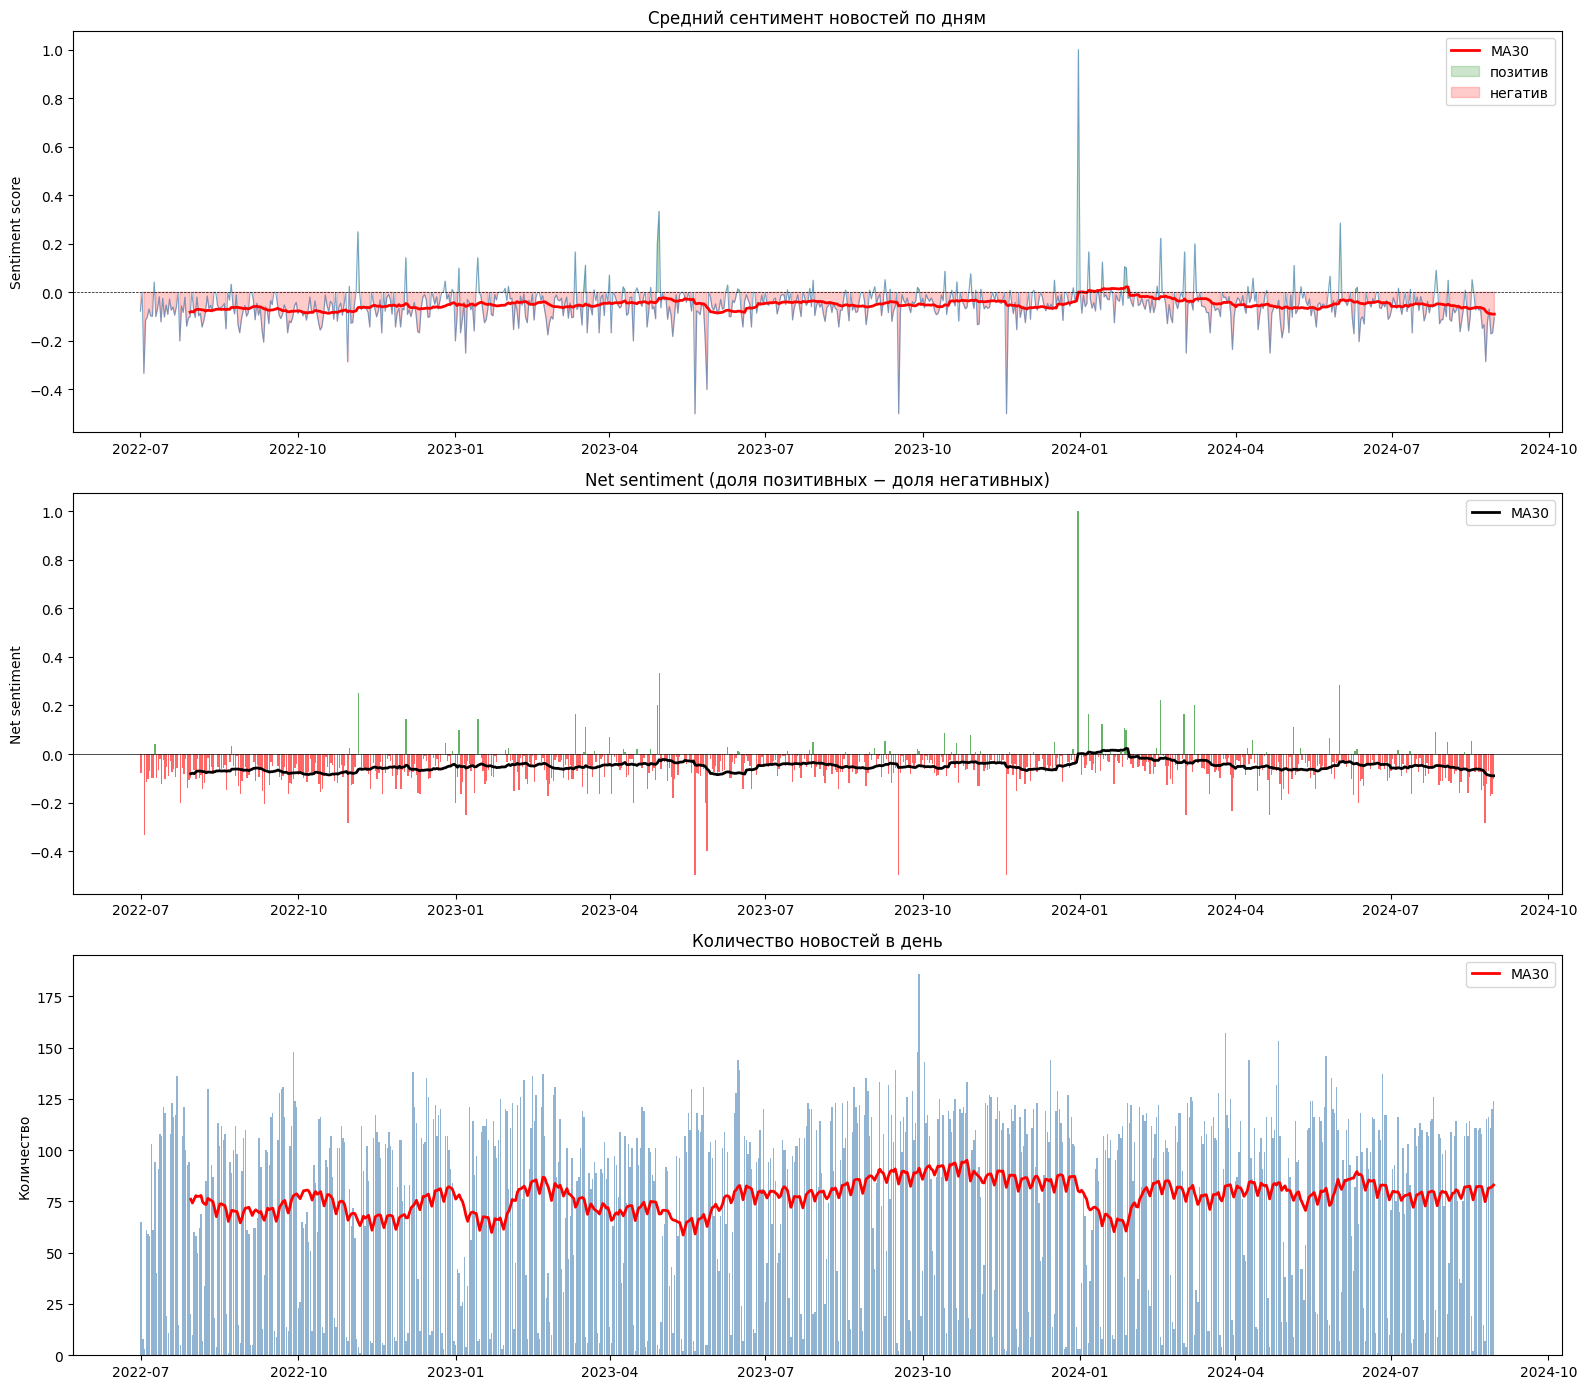

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# График 1 — средний сентимент по дням
axes[0].plot(daily_sentiment['date'], daily_sentiment['sentiment_mean'],
             color='steelblue', linewidth=0.8, alpha=0.7)
axes[0].plot(daily_sentiment['date'],
             daily_sentiment['sentiment_mean'].rolling(30).mean(),
             color='red', linewidth=2, label='MA30')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].fill_between(daily_sentiment['date'], daily_sentiment['sentiment_mean'], 0,
                     where=daily_sentiment['sentiment_mean'] > 0,
                     color='green', alpha=0.2, label='позитив')
axes[0].fill_between(daily_sentiment['date'], daily_sentiment['sentiment_mean'], 0,
                     where=daily_sentiment['sentiment_mean'] < 0,
                     color='red', alpha=0.2, label='негатив')
axes[0].set_title('Средний сентимент новостей по дням')
axes[0].set_ylabel('Sentiment score')
axes[0].legend()

# График 2 — net sentiment (позитив минус негатив)
axes[1].bar(daily_sentiment['date'], daily_sentiment['sentiment_net'],
            color=daily_sentiment['sentiment_net'].apply(
                lambda x: 'green' if x > 0 else 'red'), alpha=0.6)
axes[1].plot(daily_sentiment['date'],
             daily_sentiment['sentiment_net'].rolling(30).mean(),
             color='black', linewidth=2, label='MA30')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Net sentiment (доля позитивных − доля негативных)')
axes[1].set_ylabel('Net sentiment')
axes[1].legend()

# График 3 — количество новостей
axes[2].bar(daily_sentiment['date'], daily_sentiment['news_count'],
            color='steelblue', alpha=0.6)
axes[2].plot(daily_sentiment['date'],
             daily_sentiment['news_count'].rolling(30).mean(),
             color='red', linewidth=2, label='MA30')
axes[2].set_title('Количество новостей в день')
axes[2].set_ylabel('Количество')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/daily_sentiment.png', dpi=150)
plt.show()

In [17]:
# Сохраняем дневной сентимент
out_path = f'{PROJECT_DIR}/data/processed/daily_sentiment.csv'
daily_sentiment.to_csv(out_path, index=False)
print(f'✅ Сохранено: daily_sentiment.csv ({len(daily_sentiment)} строк)')

print('\n=== ИТОГ НОУТБУКА 03 ===')
print(f'Размечено статей:     {len(df_news):,}')
print(f'Модель:               seara/rubert-tiny2-russian-sentiment')
print(f'Дней с сентиментом:   {len(daily_sentiment)}')
print(f'Средний сентимент:    {daily_sentiment["sentiment_mean"].mean():.3f}')
print(f'Негативных дней:      {(daily_sentiment["sentiment_mean"] < 0).sum()}')
print(f'Позитивных дней:      {(daily_sentiment["sentiment_mean"] > 0).sum()}')
print(f'\nСледующий шаг: объединение с рыночными данными → ноутбук 04')

✅ Сохранено: daily_sentiment.csv (792 строк)

=== ИТОГ НОУТБУКА 03 ===
Размечено статей:     61,398
Модель:               seara/rubert-tiny2-russian-sentiment
Дней с сентиментом:   792
Средний сентимент:    -0.052
Негативных дней:      632
Позитивных дней:      72

Следующий шаг: объединение с рыночными данными → ноутбук 04
